In [1]:
# --- Setup: locate the dataset (run once per session) ---
# Colab: mount Drive, unzip MyDrive/data.zip onto the VM's local disk.
# fablab workstation (WSL2 · GTX 1080): everything durable lives in ~/navlori and
# /content is a symlink to it — so every path in this notebook works on both machines.
import importlib.util, os, sys, time, zipfile
COLAB = (importlib.util.find_spec("google") is not None
         and importlib.util.find_spec("google.colab") is not None)
if COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    ROOT = os.path.expanduser("~/navlori")
    if not os.path.islink("/content"):
        os.symlink(ROOT, "/content")

DATA = "/content/data"
if not os.path.isdir(DATA):
    t = time.time()
    with zipfile.ZipFile("/content/drive/MyDrive/data.zip" if COLAB else "/content/data.zip") as z:
        z.extractall("/content")
    print(f"unzipped to {DATA} in {time.time() - t:.0f}s")

sys.path.append(f"{DATA}/scripts")
from load_dataset import Dataset

ds = Dataset(DATA)
print(f"camera: {len(ds.camera)} frames | gt: {len(ds.gt)} poses | "
      f"span: {(ds.gt.t_ns.iloc[-1] - ds.gt.t_ns.iloc[0]) / 1e9:.1f} s | "
      f"images on disk: {len(os.listdir(f'{DATA}/camera/images'))}")

camera: 3465 frames | gt: 1004 poses | span: 116.6 s | images on disk: 3465


# 1 · The experiment at a glance

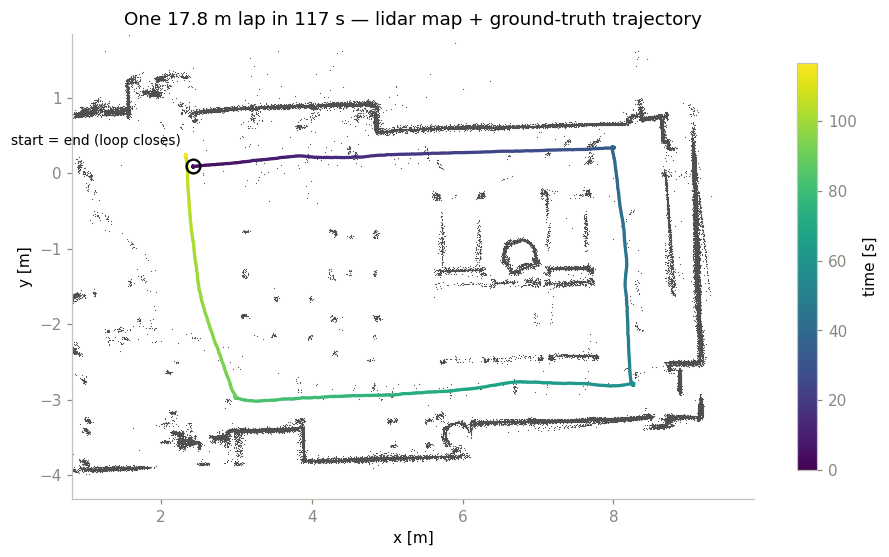

In [2]:
# Where: the ground-truth lap on the lidar map
import numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c3c2b7", "xtick.color": "#898781",
                     "ytick.color": "#898781", "grid.color": "#e1e0d9",
                     "grid.linewidth": 0.6})

mp = np.load(f"{DATA}/ground_truth/map_points.npz")["xy"]
tg = (ds.gt.t_ns - ds.gt.t_ns.iloc[0]) / 1e9

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(*mp.T, s=0.6, c="0.3", lw=0, rasterized=True)
sc = ax.scatter(ds.gt.x, ds.gt.y, c=tg, s=5, cmap="viridis", lw=0, zorder=3)
ax.plot(ds.gt.x.iloc[0], ds.gt.y.iloc[0], "o", ms=9, mfc="none", mec="k", mew=1.5, zorder=5)
ax.annotate("start = end (loop closes)", xy=(ds.gt.x.iloc[0], ds.gt.y.iloc[0]),
            xytext=(-8, 14), textcoords="offset points", fontsize=9, ha="right")
ax.set_aspect("equal"); ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_xlim(ds.gt.x.min() - 1.5, ds.gt.x.max() + 1.6)
ax.set_ylim(ds.gt.y.min() - 1.3, ds.gt.y.max() + 1.5)
fig.colorbar(sc, ax=ax, label="time [s]", shrink=0.8)
ax.set_title("One 17.8 m lap in 117 s — lidar map + ground-truth trajectory")
plt.show()

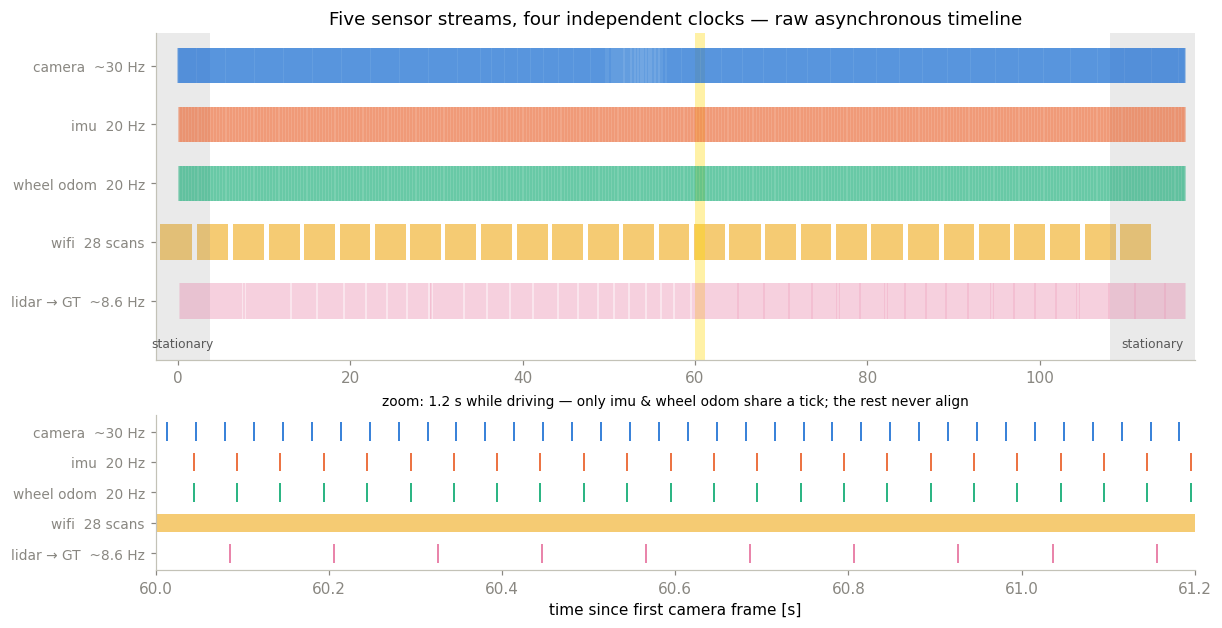

In [3]:
# When: five async streams on one clock axis
t0 = int(ds.camera.t_ns.iloc[0])
sec = lambda s: (np.asarray(s, dtype=np.int64) - t0) / 1e9
cam_t, imu_t, odo_t, gt_t = sec(ds.camera.t_ns), sec(ds.imu.t_ns), sec(ds.odom.t_ns), sec(ds.gt.t_ns)
wf = ds.wifi.groupby("scan_idx").agg(a=("t_start_ns", "first"), b=("t_end_ns", "first"))
w0, w1 = sec(wf.a), sec(wf.b)

v = np.hypot(np.diff(ds.gt.x), np.diff(ds.gt.y)) / np.diff(gt_t)
mv = np.convolve(v, np.ones(9) / 9, "same") > 0.03          # smoothed |v| vs GT noise floor
tA, tB = gt_t[np.argmax(mv)], gt_t[len(mv) - np.argmax(mv[::-1])]

rows = [("camera  ~30 Hz", cam_t, "#2a78d6"), ("imu  20 Hz", imu_t, "#eb6834"),
        ("wheel odom  20 Hz", odo_t, "#1baf7a"), ("wifi  28 scans", None, "#eda100"),
        ("lidar → GT  ~8.6 Hz", gt_t, "#e87ba4")]

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.6), height_ratios=[2.1, 1],
                             constrained_layout=True)
Z0, Z1 = 60.0, 61.2
for ax, lw_ in ((a1, 0.25), (a2, 1.2)):
    for i, (name, tt, c) in enumerate(rows):
        y = len(rows) - 1 - i
        if tt is None:
            ax.broken_barh(list(zip(w0, w1 - w0)), (y - 0.3, 0.6), color=c, alpha=0.55, lw=0)
        else:
            ax.eventplot(tt, lineoffsets=y, linelengths=0.6, colors=c, lw=lw_)
    ax.set_yticks(range(len(rows)), [r[0] for r in rows][::-1], fontsize=9)
    ax.set_ylim(-0.55, len(rows) - 0.45)
a1.set_ylim(-1.0, len(rows) - 0.45)
for (ta, tb, lab) in ((-2.6, tA, "stationary"), (tB, 118, "stationary")):
    a1.axvspan(ta, tb, color="0.55", alpha=0.18, lw=0)
    a1.text((max(ta, -2.6) + min(tb, 118)) / 2, -0.62, lab, ha="center", va="top",
            fontsize=8, color="0.35")
a1.axvspan(Z0, Z1, color="gold", alpha=0.35, lw=0)
a1.set_xlim(-2.6, 118)
a1.set_title("Five sensor streams, four independent clocks — raw asynchronous timeline")
a2.set_xlim(Z0, Z1)
a2.set_xlabel("time since first camera frame [s]")
a2.set_title("zoom: 1.2 s while driving — only imu & wheel odom share a tick; "
             "the rest never align", fontsize=9)
plt.show()

# 2 · Camera

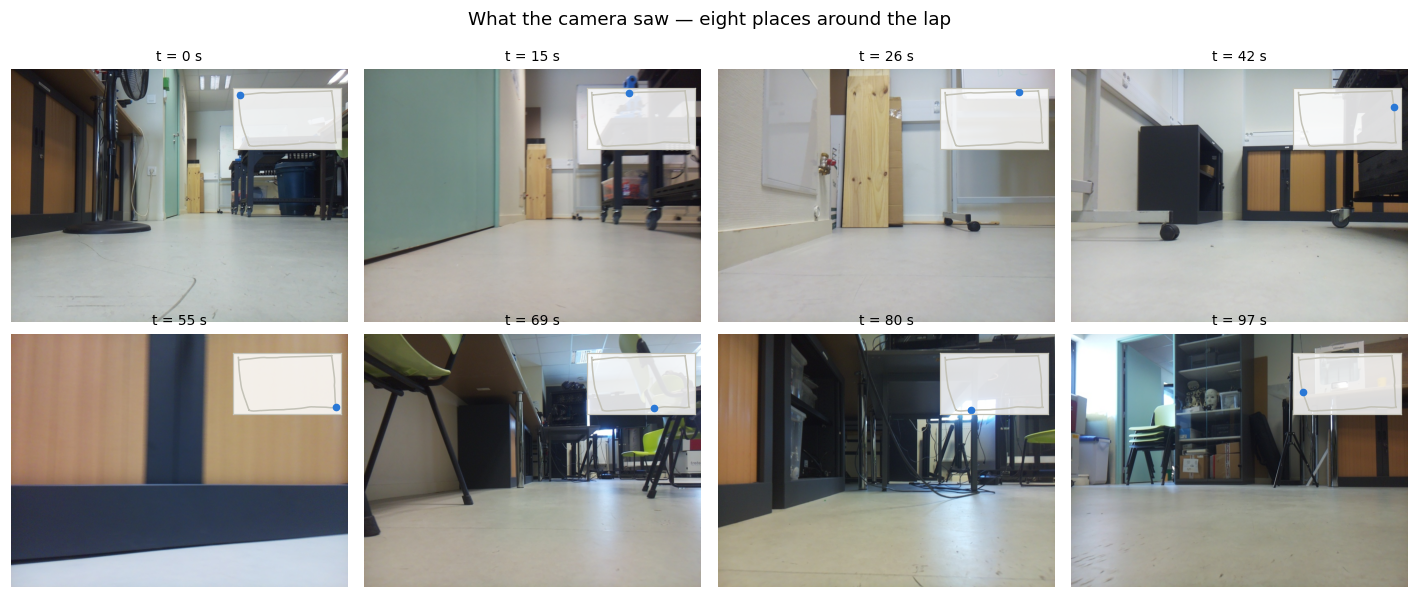

In [4]:
# Eight frames evenly spaced along the path, each located on a mini-map
from PIL import Image
CAM = "#2a78d6"
d = np.hypot(np.diff(ds.camera.x), np.diff(ds.camera.y))
s = np.concatenate([[0.0], np.cumsum(d)])
idx = np.searchsorted(s, np.linspace(0, s[-1], 9)[:-1])

fig, axes = plt.subplots(2, 4, figsize=(13, 5.4))
for ax, k in zip(axes.ravel(), idx):
    ax.imshow(Image.open(f"{DATA}/camera/images/{ds.camera.filename.iloc[k]}"))
    ax.set_title(f"t = {cam_t[k]:.0f} s", fontsize=9)
    ax.axis("off")
    ia = ax.inset_axes([0.66, 0.63, 0.32, 0.35])
    ia.patch.set_alpha(0.85)
    ia.plot(ds.gt.x, ds.gt.y, c="#c3c2b7", lw=1)
    ia.plot(ds.camera.x.iloc[k], ds.camera.y.iloc[k], "o", c=CAM, ms=4)
    ia.set_aspect("equal"); ia.set_xticks([]); ia.set_yticks([])
    for sp in ia.spines.values():
        sp.set_visible(True); sp.set_edgecolor("#c3c2b7")
fig.suptitle("What the camera saw — eight places around the lap", y=1.0)
fig.tight_layout()
plt.show()

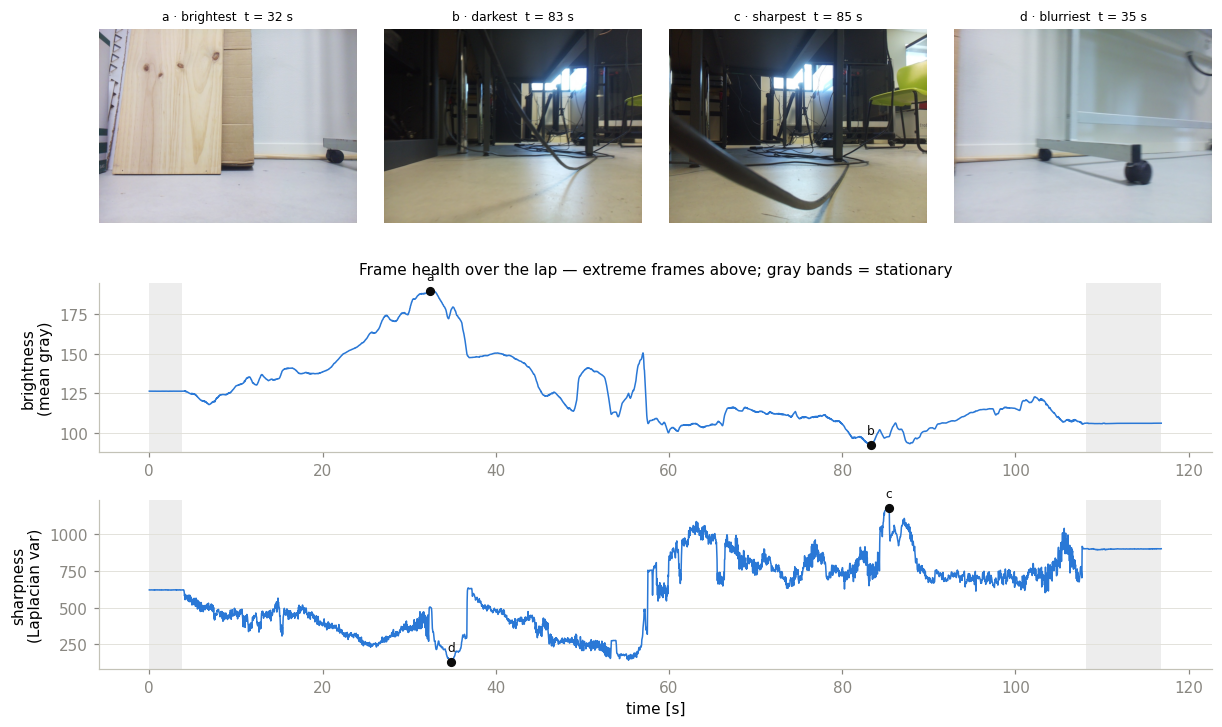

In [5]:
# Sweep all 3465 frames at 1/4 scale (grayscale) -> health traces + extreme frames
import scipy.ndimage as ndi
G = np.empty((len(ds.camera), 154, 205), np.uint8)
for i, fn in enumerate(ds.camera.filename):
    im = Image.open(f"{DATA}/camera/images/{fn}")
    im.draft("L", (205, 154))
    G[i] = np.asarray(im.convert("L").resize((205, 154)))
bright = G.mean((1, 2))
sharp = np.array([ndi.laplace(g.astype(np.float32)).var() for g in G])
frame = lambda k: Image.open(f"{DATA}/camera/images/{ds.camera.filename.iloc[k]}")

picks = [("brightest", np.argmax(bright)), ("darkest", np.argmin(bright)),
         ("sharpest", np.argmax(sharp)), ("blurriest", np.argmin(sharp))]
fig = plt.figure(figsize=(11, 6.6), constrained_layout=True)
gs = fig.add_gridspec(3, 4, height_ratios=[1.5, 1, 1])
b1 = fig.add_subplot(gs[1, :]); b2 = fig.add_subplot(gs[2, :], sharex=b1)
for j, (lab, k) in enumerate(picks):
    ta = fig.add_subplot(gs[0, j])
    ta.imshow(frame(k)); ta.axis("off")
    ta.set_title(f"{'abcd'[j]} · {lab}  t = {cam_t[k]:.0f} s", fontsize=8)
    tr, val = (b1, bright[k]) if j < 2 else (b2, sharp[k])
    tr.plot(cam_t[k], val, "o", ms=5, c="#0b0b0b", zorder=5)
    tr.annotate("abcd"[j], (cam_t[k], val), xytext=(0, 7),
                textcoords="offset points", ha="center", fontsize=8, color="#0b0b0b")
b1.plot(cam_t, bright, c=CAM, lw=1.0); b1.set_ylabel("brightness\n(mean gray)")
b2.plot(cam_t, sharp, c=CAM, lw=1.0); b2.set_ylabel("sharpness\n(Laplacian var)")
b2.set_xlabel("time [s]")
for ax in (b1, b2):
    ax.grid(True, axis="y")
    ax.axvspan(cam_t[0], tA, color="0.55", alpha=0.15, lw=0)
    ax.axvspan(tB, cam_t[-1], color="0.55", alpha=0.15, lw=0)
b1.set_title("Frame health over the lap — extreme frames above; gray bands = stationary",
             fontsize=10)
plt.show()

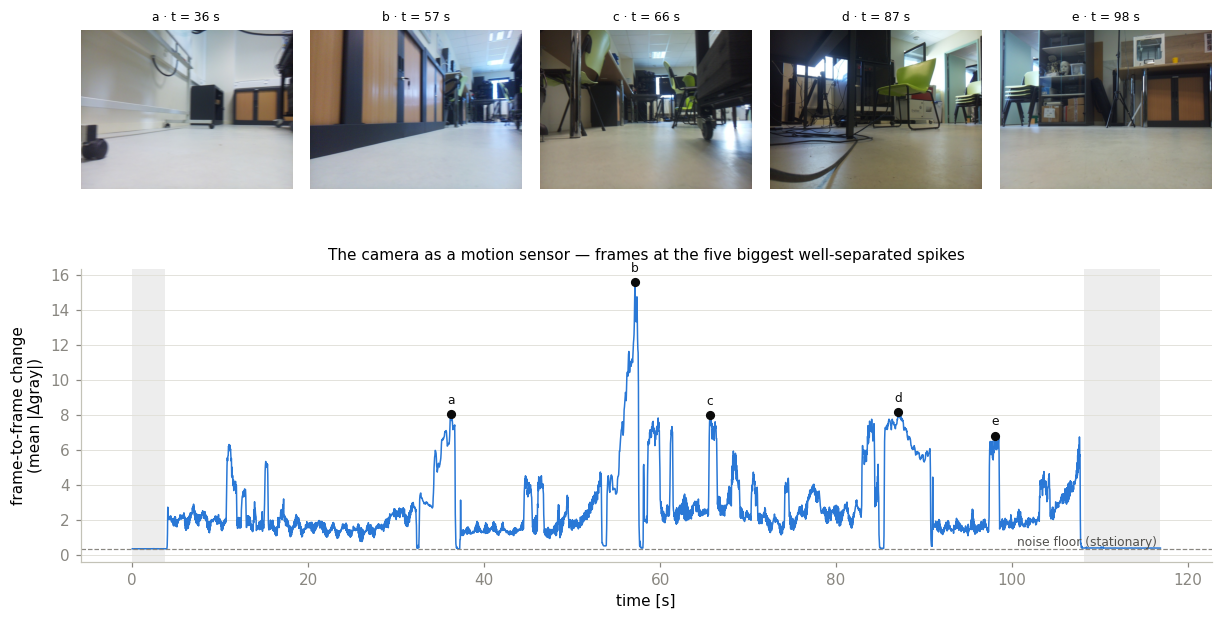

In [6]:
# The camera as a motion sensor: consecutive-frame difference + spike frames
mad = np.abs(np.diff(G.astype(np.int16), axis=0)).mean((1, 2))
floor = np.median(mad[cam_t[1:] < tA])

def spaced_peaks(t, y, k, min_sep):
    picks = []
    for i in np.argsort(y)[::-1]:
        if all(abs(t[i] - t[p]) > min_sep for p in picks):
            picks.append(i)
            if len(picks) == k:
                break
    return sorted(picks)

pk = spaced_peaks(cam_t[1:], mad, 5, min_sep=8.0)
fig = plt.figure(figsize=(11, 5.8), constrained_layout=True)
gs = fig.add_gridspec(2, 5, height_ratios=[1.5, 1.7])
ax = fig.add_subplot(gs[1, :])
for j, i in enumerate(pk):
    ta = fig.add_subplot(gs[0, j])
    ta.imshow(frame(i + 1)); ta.axis("off")
    ta.set_title(f"{'abcde'[j]} · t = {cam_t[i + 1]:.0f} s", fontsize=8)
    ax.plot(cam_t[1:][i], mad[i], "o", ms=5, c="#0b0b0b", zorder=5)
    ax.annotate("abcde"[j], (cam_t[1:][i], mad[i]), xytext=(0, 7),
                textcoords="offset points", ha="center", fontsize=8, color="#0b0b0b")
ax.plot(cam_t[1:], mad, c=CAM, lw=1.0)
ax.grid(True, axis="y")
ax.axhline(floor, c="#898781", lw=0.8, ls="--")
ax.text(cam_t[-1], floor, "noise floor (stationary) ", fontsize=8, color="#52514e",
        va="bottom", ha="right")
ax.axvspan(cam_t[0], tA, color="0.55", alpha=0.15, lw=0)
ax.axvspan(tB, cam_t[-1], color="0.55", alpha=0.15, lw=0)
ax.set_xlabel("time [s]"); ax.set_ylabel("frame-to-frame change\n(mean |Δgray|)")
ax.set_title("The camera as a motion sensor — frames at the five biggest well-separated spikes",
             fontsize=10)
plt.show()

## 2b · Prep — quality census, dedup & provisional split

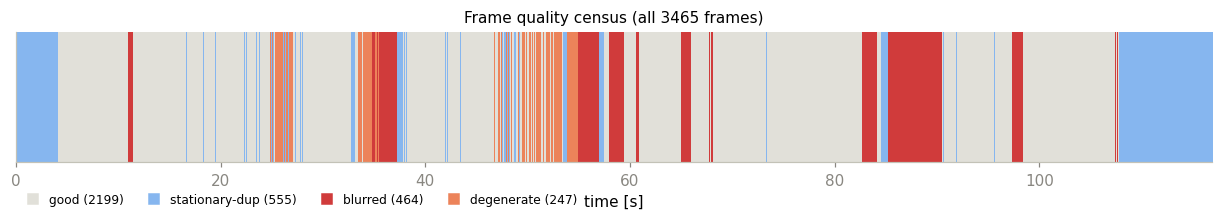

In [7]:
# Classify every frame; build the model-ready camera table `cam`
import collections
from matplotlib.colors import ListedColormap

mad_f = np.concatenate([[mad[0]], mad])                  # align diff signal to frames
stat_seg = (cam_t < tA) | (cam_t > tB)
FLOOR = np.median(mad_f[stat_seg])                       # physics noise floor
THR_STATIC = 3 * FLOOR                                   # "no visible change since previous frame"
THR_BLUR = np.percentile(mad_f[~stat_seg], 85)           # heaviest-motion frames while driving
THR_DEGEN = np.percentile(sharp, 10)                     # lowest-texture close-ups

is_static = mad_f < THR_STATIC; is_static[0] = False
episode_start = is_static & ~np.concatenate([[False], is_static[:-1]])
db_keep = ~is_static | episode_start                     # one representative per resting episode

cls = np.full(len(cam_t), "good", dtype=object)
cls[sharp < THR_DEGEN] = "degenerate"
cls[mad_f > THR_BLUR] = "blurred"
cls[is_static] = "stationary-dup"
cam = ds.camera.assign(t=cam_t, bright=bright, sharp=sharp, mad=mad_f, cls=cls, db_keep=db_keep)

CLS = [("good", "#e1e0d9"), ("stationary-dup", "#86b6ef"),
       ("blurred", "#d03b3b"), ("degenerate", "#ec835a")]
n = collections.Counter(cls)
strip = np.array([{c: i for i, (c, _) in enumerate(CLS)}[c] for c in cls])[None, :]
fig, a1 = plt.subplots(figsize=(11, 1.9), constrained_layout=True)
a1.imshow(strip, aspect="auto", cmap=ListedColormap([c for _, c in CLS]),
          interpolation="nearest", vmin=0, vmax=len(CLS) - 1,
          extent=[cam_t[0], cam_t[-1], 0, 1])
a1.set_yticks([])
a1.set_title("Frame quality census (all 3465 frames)", fontsize=10)
for c, col in CLS:
    a1.plot([], [], "s", c=col, label=f"{c} ({n[c]})")
a1.legend(loc="upper left", bbox_to_anchor=(0, -0.15), ncol=4, frameon=False,
          fontsize=8, handlelength=1.0)
a1.set_xlabel("time [s]")
plt.show()

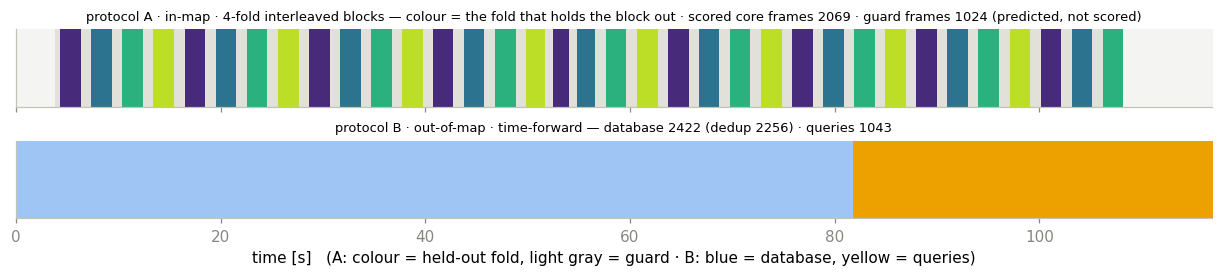

In [8]:
# Evaluation protocols — frozen here, before any method is scored (the papers' conventions,
# translated to a single traversal):
#   A "in-map":  the moving span is cut into 3-s blocks; block b belongs to fold b mod 4. Each fold
#                in turn is the QUERY set and the other three (+ the stationary lead-in/out) the
#                database — so every moving frame is predicted exactly once while held out
#                (7Scenes/MSLS separate sequences; RoboLoc same-trajectory exclusion). Scored only
#                on core frames ≥0.5 s from a block edge (no temporal near-twin in the database);
#                the guard frames are predicted too — for the whole-lap animation — never scored.
#   B "out-of-map": time-forward 75/25 — the last quarter of the lap is never in the database.
#                Measures extrapolation / robustness when leaving the mapped area.
# No validation set: every method runs its official fixed recipe (as ACE, MS-T and Reloc3r do).
BLOCK, GUARD, EVERY = 3.0, 0.5, 4
rel = cam_t - tA
blk = np.floor(rel / BLOCK).astype(int)
moving = (cam_t >= tA) & (cam_t <= tB)
cam["fold"] = np.where(moving, blk % EVERY, -1)                  # -1: stationary lead-in/out, always database
cam["core"] = ((rel - blk * BLOCK) >= GUARD) & ((rel - blk * BLOCK) <= BLOCK - GUARD)
for k in range(EVERY):
    cam[f"A{k}"] = np.where(cam.fold == k, "test", "train")
cam["B"] = np.where(cam_t < tA + 0.75 * (tB - tA), "train", "test")
SPLITS = [f"A{k}" for k in range(EVERY)] + ["B"]                 # what every method runs
PROTOCOLS = {"A": "in-map · 4-fold interleaved blocks", "B": "out-of-map · time-forward"}

fig, axs = plt.subplots(2, 1, figsize=(11, 2.4), sharex=True, constrained_layout=True)
FOLDC = [plt.cm.viridis(v) for v in (0.12, 0.38, 0.64, 0.9)]
codeA = np.where(cam.fold < 0, EVERY + 1, np.where(cam.core, cam.fold, EVERY))
axs[0].imshow(codeA[None, :], aspect="auto", cmap=ListedColormap(FOLDC + ["#e1e0d9", "#f4f4f2"]),
              interpolation="nearest", vmin=0, vmax=EVERY + 1, extent=[cam_t[0], cam_t[-1], 0, 1])
sc, gd = int(((cam.fold >= 0) & cam.core).sum()), int(((cam.fold >= 0) & ~cam.core).sum())
axs[0].set_title(f"protocol A · {PROTOCOLS['A']} — colour = the fold that holds the block out · "
                 f"scored core frames {sc} · guard frames {gd} (predicted, not scored)", fontsize=8.5)
codeB = cam.B.map({"train": 0, "test": 1}).values[None, :]
axs[1].imshow(codeB, aspect="auto", cmap=ListedColormap(["#9ec5f4", "#eda100"]), interpolation="nearest",
              vmin=0, vmax=1, extent=[cam_t[0], cam_t[-1], 0, 1])
c = collections.Counter(cam.B)
axs[1].set_title(f"protocol B · {PROTOCOLS['B']} — database {c['train']} "
                 f"(dedup {int(((cam.B == 'train') & cam.db_keep).sum())}) · queries {c['test']}", fontsize=8.5)
for ax in axs: ax.set_yticks([])
axs[-1].set_xlabel("time [s]   (A: colour = held-out fold, light gray = guard · B: blue = database, yellow = queries)")
plt.show()

# 3 · Camera — method roster under the papers' protocols (official code)

In [9]:
# Shared harness: geometry, undistortion, protocol-aware scoring, and CHECKPOINTING
# (Drive on Colab; the X:-backed ~/navlori/ckpt dir on the workstation)
import os, sys, shutil, json
import numpy as np
import pandas as pd
import torch
from scipy.spatial.transform import Rotation

RUNS = "/content/runs"; MREPOS = "/content/mrepos"
IMAGES = f"{DATA}/camera/images"
for d in (RUNS, MREPOS): os.makedirs(d, exist_ok=True)

# --- checkpointing: results under RUNS mirror to Drive; restored here; finished work is skipped ---
CKPT = "/content/drive/MyDrive/navlori_ckpt" if COLAB else "/content/ckpt"
DRIVE = os.path.isdir("/content/drive/MyDrive") if COLAB else True
METHODS = ["gem", "salad", "netvlad", "mst", "reloc3r", "ace"]
LEGACY = {**{m: f"{m}_B" for m in METHODS},                 # pre-protocol names
          **{f"{m}_A": f"{m}_A3" for m in METHODS}}         # single-fold A (= today's fold 3) -> 4-fold
for root in ([CKPT] if DRIVE else []) + [RUNS]:
    for old, new in LEGACY.items():
        if os.path.isdir(f"{root}/{old}") and not os.path.isdir(f"{root}/{new}"):
            os.rename(f"{root}/{old}", f"{root}/{new}")
            if old.endswith("_A") and os.path.exists(f"{root}/{new}/pred.csv"):
                os.remove(f"{root}/{new}/pred.csv")      # fold-3 queries grew (guard frames): re-infer, models kept
if DRIVE:
    os.makedirs(CKPT, exist_ok=True)
    shutil.copytree(CKPT, RUNS, dirs_exist_ok=True)
    print("checkpoint restored:", sorted(os.listdir(RUNS)) or "(empty)")

def keep(path):
    """Mirror a result file (under RUNS) into the Drive checkpoint."""
    if DRIVE and os.path.exists(path):
        dst = os.path.join(CKPT, os.path.relpath(path, RUNS))
        os.makedirs(os.path.dirname(dst), exist_ok=True)
        shutil.copy2(path, dst)

def have(path):
    return os.path.exists(path)

# nominal intrinsics (calib/camera_intrinsics_nominal.yaml — never calibrated, ±1-2%)
FX, FY, CX, CY = 644.1408245617476, 641.7347972317088, 398.5361240843924, 310.506616520141
K_CAM = np.array([[FX, 0, CX], [0, FY, CY], [0, 0, 1]])
DIST = np.array([0.1639958233797625, -0.271840030972792,
                 0.001055841660100477, -0.00166555973740089, 0.0])

# base_footprint -> camera optical frame (calib/extrinsics.yaml, exact values)
T_BASE_CAM = np.eye(4)
T_BASE_CAM[:3, :3] = Rotation.from_quat(
    [-0.4999998415, 0.4996018366, -0.4999998415, 0.5003981634]).as_matrix()
T_BASE_CAM[:3, 3] = [0.076, 0.0, 0.103]

def T_world_base(x, y, yaw):
    c, s = np.cos(yaw), np.sin(yaw)
    return np.array([[c, -s, 0, x], [s, c, 0, y], [0, 0, 1, 0], [0, 0, 0, 1]])

def cam_pose(x, y, yaw):                    # planar base pose -> 4x4 cam-to-world (OpenCV axes)
    return T_world_base(x, y, yaw) @ T_BASE_CAM

def base_pose(T_wc):                        # camera cam-to-world -> (x, y, yaw) of the base
    T = T_wc @ np.linalg.inv(T_BASE_CAM)
    return T[0, 3], T[1, 3], np.arctan2(T[1, 0], T[0, 0])

def undistort_into(filenames, dst_dir, resize=None, names=None):
    import cv2
    os.makedirs(dst_dir, exist_ok=True)
    for i, fn in enumerate(filenames):
        dst = os.path.join(dst_dir, names[i] if names else fn)
        if not os.path.exists(dst):
            img = cv2.undistort(cv2.imread(f"{IMAGES}/{fn}"), K_CAM, DIST)
            if resize: img = cv2.resize(img, resize, interpolation=cv2.INTER_AREA)
            cv2.imwrite(dst, img)

def sets(P):
    """(database/train, queries/test) of split P — database deduplicated, queries unfiltered.
    P = "A" is the pooled view of the four folds: every scored moving frame as a query."""
    if P == "A":
        q = (cam.fold >= 0) & cam.core
        return cam[cam.db_keep].reset_index(drop=True), cam[q].reset_index(drop=True)
    return (cam[(cam[P] == "train") & cam.db_keep].reset_index(drop=True),
            cam[cam[P] == "test"].reset_index(drop=True))

# --- scoring: the papers' metrics — per-query translation/rotation error -> median, plus
# threshold rates (5cm/5° indoor-localization standard; 25cm/5°; Recall@1 within 1 m, VPR-style)
THR = [(0.05, 5), (0.25, 5)]
PRED, RESULTS = {}, {}
GTL = cam.set_index("filename")

def _score(name, df, show=False):
    m, P = name.rsplit("_", 1)
    j = df.join(GTL, on="frame", rsuffix="_gt")
    if P.startswith("A"): j = j[j.core.values]         # in-map: guard frames are predicted, never scored
    PRED[name] = j
    dp = np.hypot(j.x - j.x_gt, j.y - j.y_gt).values
    dy = np.degrees(np.abs((j.yaw - j.yaw_gt + np.pi) % (2 * np.pi) - np.pi)).values
    r = dict(n=len(j), med_cm=float(np.median(dp) * 100), med_deg=float(np.nanmedian(dy)),
             r1_1m=float((dp <= 1.0).mean() * 100))
    for t, a in THR:
        r[f"acc_{int(t*100)}cm_{a}deg"] = float(
            ((dp <= t) & (np.nan_to_num(dy, nan=1e9) <= a)).mean() * 100)
    r["by_class"] = {c: float(np.median(dp[(j.cls == c).values]) * 100)
                     for c in ["good", "blurred", "degenerate", "stationary-dup"] if (j.cls == c).any()}
    RESULTS[name] = r
    if show: print(f"[{P} {PROTOCOLS[P].split(' ·')[0]:>10}] {m:<8} n={r['n']:<4} median {r['med_cm']:6.1f} cm /"
          f" {r['med_deg']:5.1f}°  |  ≤5cm∧5°: {r['acc_5cm_5deg']:4.1f}%  ≤25cm∧5°: {r['acc_25cm_5deg']:4.1f}%"
          f"  R@1≤1m: {r['r1_1m']:4.1f}%  |  class medians cm: "
          + "  ".join(f"{c[:5]} {v:.0f}" for c, v in r["by_class"].items()))
    return r

def smoke(name, frames, x, y, yaw=None):
    df = pd.DataFrame(dict(frame=list(frames), x=x, y=y, yaw=np.nan if yaw is None else yaw))
    os.makedirs(f"{RUNS}/{name}", exist_ok=True)
    df.to_csv(f"{RUNS}/{name}/pred.csv", index=False)
    keep(f"{RUNS}/{name}/pred.csv")
    return _score(name, df)

def done(name):
    """True if <name> already has a pred.csv (this session or restored) — rescores it quietly."""
    p = f"{RUNS}/{name}/pred.csv"
    if os.path.exists(p):
        _score(name, pd.read_csv(p))
        return True
    return False

def pool(m):
    """Report a method: A = its four folds together (one held-out prediction per moving frame), then B."""
    _score(f"{m}_A", pd.concat([pd.read_csv(f"{RUNS}/{m}_A{k}/pred.csv") for k in range(EVERY)]), show=True)
    _score(f"{m}_B", pd.read_csv(f"{RUNS}/{m}_B/pred.csv"), show=True)

DBb, Qb = sets("B")
print(f"protocol A: {EVERY} folds, database ≈ {int(np.mean([len(sets(P)[0]) for P in SPLITS[:-1]]))} each | "
      f"scored queries {len(sets('A')[1])} (+{int(((cam.fold >= 0) & ~cam.core).sum())} guard frames predicted, not scored)")
print(f"protocol B: database {len(DBb)} | queries {len(Qb)}")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — enable T4!")

checkpoint restored: ['STATUS', 'ace_A0', 'ace_A1', 'ace_A2', 'ace_A3', 'ace_B', 'dpvo', 'gem_A0', 'gem_A1', 'gem_A2', 'gem_A3', 'gem_B', 'gifs', 'mst_A0', 'mst_A1', 'mst_A2', 'mst_A3', 'mst_B', 'netvlad', 'netvlad_A0', 'netvlad_A1', 'netvlad_A2', 'netvlad_A3', 'netvlad_B', 'reloc3r_A0', 'reloc3r_A1', 'reloc3r_A2', 'reloc3r_A3', 'reloc3r_B', 'salad_A0', 'salad_A1', 'salad_A2', 'salad_A3', 'salad_B', 'side_navlori_camera.run.ipynb', 'smoke_0_12.out.ipynb', 'table_camera_A_B.csv', 'table_camera_VO.csv']


protocol A: 4 folds, database ≈ 2255 each | scored queries 2069 (+1024 guard frames predicted, not scored)
protocol B: database 2256 | queries 1043
GPU: NVIDIA GeForce GTX 1080


In [10]:
# B1 · Retrieval floor — frozen ResNet50 (ImageNet weights) + GeM pooling, top-1 database pose
import torchvision
from PIL import Image
from torchvision import transforms as T

if not all(done(f"gem_{P}") for P in SPLITS):
    body = torch.nn.Sequential(*list(torchvision.models.resnet50(
        weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2).children())[:-2]).eval().cuda()
    tf = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor(),
                    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    @torch.inference_mode()
    def gem_desc(files, p=3.0):
        D = np.zeros((len(files), 2048), np.float32)
        for i in range(0, len(files), 48):
            x = torch.stack([tf(Image.open(f"{IMAGES}/{f}").convert("RGB"))
                             for f in files[i:i + 48]]).cuda()
            with torch.autocast("cuda", torch.float16):
                d = body(x).clamp(min=1e-6).pow(p).mean((-2, -1)).pow(1 / p).float()   # GeM pool
            D[i:i + len(x)] = torch.nn.functional.normalize(d, dim=1).cpu().numpy()
        return D

    Dall = dict(zip(cam.filename, gem_desc(list(cam.filename))))      # one descriptor per frame
    for P in SPLITS:
        if done(f"gem_{P}"): continue
        DB, Q = sets(P)
        Ddb = np.stack([Dall[f] for f in DB.filename]); Dq = np.stack([Dall[f] for f in Q.filename])
        nn = (Dq @ Ddb.T).argmax(1)                  # cosine similarity (descriptors L2-normalized)
        smoke(f"gem_{P}", Q.filename, DB.x.values[nn], DB.y.values[nn], DB.yaw.values[nn])
pool("gem")


[A     in-map] gem      n=2069 median   21.2 cm /   0.7°  |  ≤5cm∧5°:  1.9%  ≤25cm∧5°: 47.3%  R@1≤1m: 99.9%  |  class medians cm: good 22  blurr 12  degen 19  stati 24
[B out-of-map] gem      n=1043 median  341.1 cm /  84.5°  |  ≤5cm∧5°:  0.6%  ≤25cm∧5°:  3.2%  R@1≤1m: 16.8%  |  class medians cm: good 293  blurr 228  stati 348


In [11]:
# R2b · DINOv2-SALAD (CVPR 2024, serizba/salad @6aede13, GPL-3.0) — official model via torch.hub
if not all(done(f"salad_{P}") for P in SPLITS):
    %pip -q install "pytorch-lightning>=2.1,<3" pytorch-metric-learning faiss-cpu prettytable
    from PIL import Image
    from torchvision import transforms as T
    salad = torch.hub.load("serizba/salad:6aede13a3f6c25750bf7fde10209c06cb73060bb",
                           "dinov2_salad", trust_repo=True).eval().cuda()
    tf = T.Compose([T.Resize((322, 322), interpolation=T.InterpolationMode.BILINEAR),
                    T.ToTensor(), T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

    @torch.inference_mode()
    def salad_desc(files):
        D = np.zeros((len(files), 8448), np.float32)
        for i in range(0, len(files), 32):
            x = torch.stack([tf(Image.open(f"{IMAGES}/{f}").convert("RGB"))
                             for f in files[i:i + 32]]).cuda()
            with torch.autocast("cuda", torch.float16):
                D[i:i + len(x)] = salad(x).float().cpu().numpy()
        return D

    Dall = dict(zip(cam.filename, salad_desc(list(cam.filename))))
    for P in SPLITS:
        if done(f"salad_{P}"): continue
        DB, Q = sets(P)
        Ddb = np.stack([Dall[f] for f in DB.filename]); Dq = np.stack([Dall[f] for f in Q.filename])
        nn = (Dq @ Ddb.T).argmax(1)
        smoke(f"salad_{P}", Q.filename, DB.x.values[nn], DB.y.values[nn], DB.yaw.values[nn])
pool("salad")


[A     in-map] salad    n=2069 median   20.1 cm /   0.7°  |  ≤5cm∧5°:  1.3%  ≤25cm∧5°: 53.9%  R@1≤1m: 99.7%  |  class medians cm: good 21  blurr 12  degen 22  stati 27
[B out-of-map] salad    n=1043 median  264.3 cm /  85.1°  |  ≤5cm∧5°:  0.5%  ≤25cm∧5°:  3.4%  R@1≤1m: 13.6%  |  class medians cm: good 230  blurr 137  stati 665


In [12]:
%%bash
# B3 · NetVLAD — official hloc toolbox (cvg/Hierarchical-Localization @c13273b, Apache-2.0)
set -e
[ -f /content/runs/netvlad_A/pred.csv ] && [ -f /content/runs/netvlad_B/pred.csv ] \
  && { echo "netvlad done — skipping install"; exit 0; }
if [ ! -d /content/mrepos/hloc ]; then
  git clone -q --recursive https://github.com/cvg/Hierarchical-Localization.git /content/mrepos/hloc
  cd /content/mrepos/hloc && git checkout -q c13273bd0ecc2917a35910fd843712a1c6243193 \
    && git submodule update -q --init --recursive
fi
pip install -q -e /content/mrepos/hloc

In [13]:
# official extractor over ALL frames once -> per-protocol top-1 neighbor -> matched frame's pose
if not all(done(f"netvlad_{P}") for P in SPLITS):
    import h5py
    d = f"{RUNS}/netvlad/images"; os.makedirs(d, exist_ok=True)
    for fn in cam.filename:
        if not os.path.lexists(f"{d}/{fn}"): os.symlink(f"{IMAGES}/{fn}", f"{d}/{fn}")
    !python -m hloc.extract_features --conf netvlad --image_dir {RUNS}/netvlad/images --export_dir {RUNS}/netvlad --as_half
    with h5py.File(f"{RUNS}/netvlad/global-feats-netvlad.h5", "r") as fd:
        Dall = {n: fd[n]["global_descriptor"][...].astype(np.float32) for n in fd.keys()}
    for P in SPLITS:
        if done(f"netvlad_{P}"): continue
        DB, Q = sets(P)
        Ddb = np.stack([Dall[f] for f in DB.filename]); Dq = np.stack([Dall[f] for f in Q.filename])
        nn = (Dq @ Ddb.T).argmax(1)
        smoke(f"netvlad_{P}", Q.filename, DB.x.values[nn], DB.y.values[nn], DB.yaw.values[nn])
pool("netvlad")


[A     in-map] netvlad  n=2069 median   19.5 cm /   0.7°  |  ≤5cm∧5°:  1.2%  ≤25cm∧5°: 53.2%  R@1≤1m: 99.6%  |  class medians cm: good 21  blurr 12  degen 19  stati 21
[B out-of-map] netvlad  n=1043 median  239.6 cm /  92.8°  |  ≤5cm∧5°:  0.7%  ≤25cm∧5°:  3.1%  R@1≤1m: 18.2%  |  class medians cm: good 234  blurr 76  stati 647


In [14]:
%%bash
# B2 · MS-Transformer (ICCV 2021, yolish/multi-scene-pose-transformer @56ca699; authors' code, no license file)
set -e
[ -f /content/runs/mst_A/pred.csv ] && [ -f /content/runs/mst_B/pred.csv ] \
  && { echo "mst done — skipping install"; exit 0; }
if [ ! -d /content/mrepos/mst ]; then
  git clone -q https://github.com/yolish/multi-scene-pose-transformer.git /content/mrepos/mst
  cd /content/mrepos/mst && git checkout -q 56ca699fa61ad689f3631231c03608e46c9c7938
fi
pip install -q efficientnet-pytorch==0.7.1

In [15]:
# adapter: our GT -> their 7Scenes-style CSV; train their entry point unchanged, once per split
# (4 folds + B, ~45 min each; skipped when the trained model is checkpointed)
import runpy, types, torchvision.ops, torchvision.ops.misc

def labels_csv(rows, path, split):                       # poses fed as-is: planar base pose,
    with open(path, "w") as f:                           # scalar-first quaternion from yaw
        f.write("scene,split,seq,img_path,t1,t2,t3,q1,q2,q3,q4\n")
        for r in rows.itertuples():
            f.write(f"myroom,{split},0,{r.filename},{r.x},{r.y},0.0,"
                    f"{np.cos(r.yaw / 2)},0.0,0.0,{np.sin(r.yaw / 2)}\n")

# their repo folders (datasets/, models/, util/) have no __init__.py -> namespace packages, which
# LOSE to installed packages of the same name (HuggingFace `datasets` on Colab!). Pin all three:
def pin_mst():
    for pkg in ["datasets", "models", "util"]:
        mod = types.ModuleType(pkg); mod.__path__ = [f"{MREPOS}/mst/{pkg}"]; sys.modules[pkg] = mod
    if not hasattr(torchvision.ops, "_new_empty_tensor"):        # two symbols their old-torchvision
        torchvision.ops._new_empty_tensor = lambda x, s: x.new_empty(s)   # guard imports but never calls
    if not hasattr(torchvision.ops.misc, "_output_size"):
        torchvision.ops.misc._output_size = lambda d, i, s=None, f=None: []
    os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"          # torch>=2.6 legacy-pickle load

mst_cfg = {}
for P in SPLITS:
    out = f"{RUNS}/mst_{P}"; os.makedirs(out, exist_ok=True)
    DB, Q = sets(P)
    labels_csv(DB, f"{out}/train.csv", "train"); labels_csv(Q, f"{out}/test.csv", "test")
    cfg = json.load(open(f"{MREPOS}/mst/7Scenes_config.json")) if os.path.exists(
        f"{MREPOS}/mst/7Scenes_config.json") else json.load(open(f"{out}/config.json"))
    cfg["ems-transposenet"]["num_scenes"] = 1
    cfg["general"].update(n_workers=2, n_freq_print=100)
    json.dump(cfg, open(f"{out}/config.json", "w"), indent=1); keep(f"{out}/config.json")
    mst_cfg[P] = cfg
    if have(f"{out}/final.pth") or have(f"{out}/pred.csv"):
        print(f"mst_{P}: model/result checkpointed — skipping training"); continue
    pin_mst()
    os.chdir(f"{MREPOS}/mst"); sys.path.insert(0, f"{MREPOS}/mst")
    sys.argv = ["main.py", "ems-transposenet", "train", "./models/backbones/efficient-net-b0.pth",
                IMAGES, f"{out}/train.csv", f"{out}/config.json", "--experiment", f"myroom_{P}"]
    runpy.run_path("main.py", run_name="__main__")       # their official entry point, unchanged
    os.chdir("/content")
    import glob
    ck = max(glob.glob(f"{MREPOS}/mst/out/run_*_final.pth"), key=os.path.getmtime)
    shutil.copy2(ck, f"{out}/final.pth"); keep(f"{out}/final.pth")

mst_A0: model/result checkpointed — skipping training
mst_A1: model/result checkpointed — skipping training
mst_A2: model/result checkpointed — skipping training
mst_A3: model/result checkpointed — skipping training
mst_B: model/result checkpointed — skipping training


In [16]:
# dump per-frame poses (their model + dataset as an unchanged library) and score, per split
for P in SPLITS:
    if done(f"mst_{P}"): continue
    pin_mst()
    from util import utils
    from datasets.CameraPoseDataset import CameraPoseDataset
    from models.pose_regressors import get_model
    out = f"{RUNS}/mst_{P}"
    config = {**mst_cfg[P]["ems-transposenet"], **mst_cfg[P]["general"]}
    os.chdir(f"{MREPOS}/mst")
    model = get_model("ems-transposenet", "./models/backbones/efficient-net-b0.pth", config).cuda()
    model.load_state_dict(torch.load(f"{out}/final.pth")); model.eval()
    ds_test = CameraPoseDataset(IMAGES, f"{out}/test.csv", utils.test_transforms.get("baseline"))
    Pz = []
    with torch.no_grad():                                # mirrors their official test path (batch 1, scene=None)
        for mb in torch.utils.data.DataLoader(ds_test, batch_size=1, shuffle=False, num_workers=2):
            for k, v in mb.items(): mb[k] = v.cuda()
            mb["scene"] = None
            Pz.append(model(mb)["pose"].cpu().numpy())
    Pz = np.concatenate(Pz); os.chdir("/content")
    _, Q = sets(P)
    smoke(f"mst_{P}", Q.filename, Pz[:, 0], Pz[:, 1], 2 * np.arctan2(Pz[:, 6], Pz[:, 3]))
pool("mst")


[A     in-map] mst      n=2069 median   10.4 cm /   2.8°  |  ≤5cm∧5°: 11.7%  ≤25cm∧5°: 70.4%  R@1≤1m: 99.9%  |  class medians cm: good 9  blurr 12  degen 15  stati 13
[B out-of-map] mst      n=1043 median  405.2 cm /  84.6°  |  ≤5cm∧5°:  0.0%  ≤25cm∧5°:  2.0%  R@1≤1m:  5.5%  |  class medians cm: good 363  blurr 317  stati 509


In [17]:
%%bash
# R1 · ACE (CVPR 2023, nianticlabs/ace @e9e90f2, non-commercial) — builds the DSAC* pose solver
set -e
[ -f /content/runs/ace_A/pred.csv ] && [ -f /content/runs/ace_B/pred.csv ] \
  && [ -f /content/runs/ace_A/test_navlori_sanity_s.txt ] && [ -f /content/runs/ace_B/test_navlori_sanity_s.txt ] \
  && { echo "ace done — skipping install"; exit 0; }
if [ ! -d /content/mrepos/ace ]; then
  git clone -q https://github.com/nianticlabs/ace.git /content/mrepos/ace
  cd /content/mrepos/ace && git checkout -q e9e90f2d02ee92c348bf411a5a60e230af6c315e
fi
python -c "
import pathlib
s = pathlib.Path('/content/mrepos/ace/ace_encoder_pretrained.pt').stat().st_size
assert s == 22278371, f'encoder looks like an LFS pointer: {s} bytes'"
apt-get -qq update && apt-get -qq install -y libopencv-dev > /dev/null
pip install -q pyrender trimesh
# guard must ask for the FUNCTION, not just the module: a failed install can leave an empty
# namespace-package ghost in site-packages that imports fine but contains nothing
cd /content && python -c "import torch, dsacstar; dsacstar.forward_rgb" 2>/dev/null || \
  (pip uninstall -y -q dsacstar 2>/dev/null; \
   cd /content/mrepos/ace/dsacstar && CONDA_PREFIX=/usr pip install -q --no-build-isolation --force-reinstall .)
cd /content && python -c "import torch, dsacstar; dsacstar.forward_rgb; print('dsacstar OK:', dsacstar.__file__)"

W: https://nvidia.github.io/libnvidia-container/stable/deb/amd64/InRelease: Key is stored in legacy 

trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
W

: https://nvidia.github.io/libnvidia-container/stable/ubuntu18.04/amd64/InRelease: Key is stored in 

legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for det

ails.


dsacstar OK: /root/navlori/venv/lib/python3.10/site-packages/dsacstar.cpython-310-x86_64-linux-gnu.s

o


In [18]:
# adapter: undistorted frames + 4x4 cam-to-world poses (OpenCV axes) + 3x3 K files; their official
# train (fixed recipe) + test, once per split (4 folds + B, ~25 min each)
import runpy
f_mean = (FX + FY) / 2                                   # ACE asserts fx == fy; 0.2% averaging error

def stage_ace(rows, folder):
    for sub in ["rgb", "poses", "calibration"]:
        os.makedirs(f"{folder}/{sub}", exist_ok=True)
    undistort_into(list(rows.filename), f"{folder}/rgb",
                   names=[f"frame-{i:06d}.color.jpg" for i in range(len(rows))])
    for i, r in enumerate(rows.itertuples()):
        np.savetxt(f"{folder}/poses/frame-{i:06d}.pose.txt", cam_pose(r.x, r.y, r.yaw))
        with open(f"{folder}/calibration/frame-{i:06d}.calibration.txt", "w") as f:
            f.write(f"{f_mean} 0 {CX}\n0 {f_mean} {CY}\n0 0 1\n")

for P in SPLITS:
    if done(f"ace_{P}"): continue
    DB, Q = sets(P)
    scene, head = f"{RUNS}/ace_{P}/navlori", f"{RUNS}/ace_{P}/navlori.pt"
    stage_ace(DB, f"{scene}/train"); stage_ace(Q, f"{scene}/test")
    if not have(head):
        # torch>=2.5 removed the LR scheduler's private optimizer._step_count patching that ACE
        # reads to detect fp16-skipped steps; recreate the old semantic (their code untouched)
        _orig_step = torch.optim.AdamW.step
        def _counted_step(self, *a, **k):
            out = _orig_step(self, *a, **k)
            self._step_count = getattr(self, "_step_count", 0) + 1
            return out
        torch.optim.AdamW.step = _counted_step; torch.optim.AdamW._step_count = 0
        os.chdir(f"{MREPOS}/ace")
        sys.argv = ["train_ace.py", scene, head, "--training_buffer_size", "4000000"]
        runpy.run_path("train_ace.py", run_name="__main__")   # their official entry point, unchanged
        torch.optim.AdamW.step = _orig_step
        os.chdir("/content"); keep(head)
    !cd {MREPOS}/ace && python test_ace.py {scene} {head} --session run1
    # their poses file is WORLD-TO-CAM with a qw-first quaternion -> invert, convert to base frame
    rec = []
    for line in open(f"{RUNS}/ace_{P}/poses_navlori_run1.txt"):
        p = line.split()
        T = np.eye(4)
        T[:3, :3] = Rotation.from_quat([float(p[2]), float(p[3]), float(p[4]), float(p[1])]).as_matrix()
        T[:3, 3] = [float(p[5]), float(p[6]), float(p[7])]
        rec.append((int(p[0][6:12]), *base_pose(np.linalg.inv(T))))
    rec.sort()
    smoke(f"ace_{P}", Q.filename, [r[1] for r in rec], [r[2] for r in rec], [r[3] for r in rec])
pool("ace")


[A     in-map] ace      n=2069 median    3.9 cm /   0.5°  |  ≤5cm∧5°: 59.1%  ≤25cm∧5°: 89.6%  R@1≤1m: 99.4%  |  class medians cm: good 3  blurr 9  degen 4  stati 6
[B out-of-map] ace      n=1043 median  633.6 cm /  78.5°  |  ≤5cm∧5°:  2.7%  ≤25cm∧5°:  7.0%  R@1≤1m: 17.8%  |  class medians cm: good 607  blurr 78  stati 1064


In [19]:
# ACE upper bound per protocol: evaluate on every 10th DATABASE view (seen viewpoints) — separates
# method/pipeline health from what the split makes impossible
for P in ["A3", "B"]:
    res = f"{RUNS}/ace_{P}/test_navlori_sanity_s.txt"
    if not have(res):
        DB, _ = sets(P)
        stage_ace(DB.iloc[::10].reset_index(drop=True), f"{RUNS}/ace_{P}/navlori_sanity/test")
        !cd {MREPOS}/ace && python test_ace.py {RUNS}/ace_{P}/navlori_sanity {RUNS}/ace_{P}/navlori.pt --session s
        keep(res)
    r_err, t_err, _ = open(res).read().split()
    RESULTS[f"ace_seen_{P[0]}"] = dict(med_cm=float(t_err), med_deg=float(r_err))
    print(f"[{P}] ace on SEEN database views: median {float(t_err):.1f} cm / {float(r_err):.2f}°")

[A3] ace on SEEN database views: median 1.1 cm / 0.24°
[B] ace on SEEN database views: median 0.9 cm / 0.22°


In [20]:
%%bash
# R2 · Reloc3r-512 (CVPR 2025, ffrivera0/reloc3r @761fac6, CC BY-NC-SA) — pretrained, no scene training
set -e
[ -f /content/runs/reloc3r_A/pred.csv ] && [ -f /content/runs/reloc3r_B/pred.csv ] \
  && { echo "reloc3r done — skipping install"; exit 0; }
if [ ! -d /content/mrepos/reloc3r ]; then
  git clone -q --recursive https://github.com/ffrivera0/reloc3r.git /content/mrepos/reloc3r
  cd /content/mrepos/reloc3r && git checkout -q 761fac648e9c21fd7dcda01ab2ccd4fc20058102 \
    && git submodule update -q --init --recursive
fi
pip install -q roma matplotlib tqdm opencv-python scipy einops tensorboard \
  'huggingface-hub[torch]>=0.22' imagesize

In [21]:
# adapter: fake 7Scenes 'heads' tree — EXACTLY 1000 db + 1000 query frames (their loader hardcodes it;
# the database is subsampled uniformly — a deviation from their full-database default, forced by
# the code), undistorted AND resized to 640x480 (their loader crops around a HARDCODED principal
# point (320,240)). Their official eval (NetVLAD top-10 + relative pose, ~30 min), then their
# motion averaging recovers absolute poses. Per split: 4 folds + B.
def pick(rows, n):
    return rows.iloc[np.linspace(0, len(rows) - 1, n).round().astype(int)].reset_index(drop=True)

for P in SPLITS:
    if done(f"reloc3r_{P}"): continue
    DB, Q = sets(P)
    root = f"{RUNS}/reloc3r_{P}/7scenes/heads"
    r3_db, r3_q = pick(DB, 1000), pick(Q, 1000)
    for seq, rows in [("seq-02", r3_db), ("seq-01", r3_q)]:
        undistort_into(list(rows.filename), f"{root}/{seq}", resize=(640, 480),
                       names=[f"frame-{i:06d}.color.png" for i in range(len(rows))])
        for i, r in enumerate(rows.itertuples()):
            np.savetxt(f"{root}/{seq}/frame-{i:06d}.pose.txt", cam_pose(r.x, r.y, r.yaw))
    os.makedirs(f"{MREPOS}/reloc3r/data", exist_ok=True)
    !ln -sfn {RUNS}/reloc3r_{P}/7scenes {MREPOS}/reloc3r/data/7scenes
    !cd {MREPOS}/reloc3r && rm -rf _db-q_pair_info && python eval_visloc.py --model "Reloc3rRelpose(img_size=512)" \
      --dataset_db "SevenScenesRetrieval(scene='{{}}', split='train')" \
      --dataset_q "SevenScenesRetrieval(scene='{{}}', split='test')" \
      --dataset_relpose "SevenScenesRelpose(scene='{{}}', pair_id={{}}, resolution={{}})" \
      --scene "heads" --topk 10 --batch_size 8 --num_workers 2 --amp 1
    # recover absolute poses: their eval only prints medians — re-run their motion averaging
    sys.path.insert(0, f"{MREPOS}/reloc3r")
    from reloc3r.reloc3r_visloc import Reloc3rVisloc
    va, cache = Reloc3rVisloc(), f"{MREPOS}/reloc3r/_db-q_pair_info"
    xs, ys, yaws = [], [], []
    for fid in range(1000):
        pdb = [np.loadtxt(f"{cache}/poses_heads_pair-id={k}/seq-01_{fid:06d}_pose-db.txt") for k in range(10)]
        pq2 = [np.loadtxt(f"{cache}/poses_heads_pair-id={k}/seq-01_{fid:06d}_pose-q2d.txt") for k in range(10)]
        x, y, w = base_pose(va.motion_averaging(pdb, pq2)); xs.append(x); ys.append(y); yaws.append(w)
    dfp = pd.DataFrame(dict(frame=r3_q.filename, x=xs, y=ys, yaw=yaws)).drop_duplicates("frame")
    smoke(f"reloc3r_{P}", dfp.frame, dfp.x.values, dfp.y.values, dfp.yaw.values)
pool("reloc3r")


[A     in-map] reloc3r  n=2069 median   28.2 cm /   0.5°  |  ≤5cm∧5°: 13.0%  ≤25cm∧5°: 41.0%  R@1≤1m: 89.4%  |  class medians cm: good 38  blurr 5  degen 23  stati 15
[B out-of-map] reloc3r  n=1000 median  341.4 cm / 164.7°  |  ≤5cm∧5°:  0.3%  ≤25cm∧5°:  8.4%  R@1≤1m: 23.9%  |  class medians cm: good 312  blurr 73  stati 652


In [22]:
%%bash
# R3 · DPVO (NeurIPS 2023, princeton-vl/DPVO @859bbbf, MIT) — own Python-3.11 venv: its CUDA ops need
# torch 2.3.1, and Colab's Python (3.13) has no such wheels. First run ~20-30 min (CUDA compile).
set -e
[ -f /content/runs/dpvo/summary.json ] && { echo "dpvo done — skipping install"; exit 0; }
V=/content/venvs/dpvo
if [ ! -d /content/mrepos/DPVO ]; then
  git clone -q --recursive https://github.com/princeton-vl/DPVO.git /content/mrepos/DPVO
  cd /content/mrepos/DPVO && git checkout -q 859bbbfdac6c6185f345003b3c473901fcd13ace
fi
if [ ! -f $V/ok ]; then
  rm -rf $V                                   # wipe any half-created venv from a failed attempt
  pip install -q uv
  uv venv -q --python 3.11 $V                 # uv provisions a managed CPython 3.11 for this venv
  UVP="uv pip install -q --python $V/bin/python"
  $UVP setuptools wheel
  $UVP torch==2.3.1 torchvision==0.18.1 --index-url https://download.pytorch.org/whl/cu121
  $UVP numpy==1.26.4 'opencv-python<4.11' evo plyfile yacs tqdm einops numba pypose kornia scipy tensorboard
  $UVP torch-scatter -f https://data.pyg.org/whl/torch-2.3.0+cu121.html
  cd /content/mrepos/DPVO
  [ -d thirdparty/eigen-3.4.0 ] || (wget -q https://gitlab.com/libeigen/eigen/-/archive/3.4.0/eigen-3.4.0.zip \
     && unzip -qo eigen-3.4.0.zip -d thirdparty)
  TORCH_CUDA_ARCH_LIST="6.1;7.5" $UVP --no-build-isolation .
  [ -f dpvo.pth ] || (gdown -q 1dRqftpImtHbbIPNBIseCv9EvrlHEnjhX -O models.zip && unzip -qo models.zip)
  MPLBACKEND=Agg $V/bin/python -c "from dpvo.dpvo import DPVO; print('DPVO import OK')"
  touch $V/ok
fi

dpvo done — skipping install


In [23]:
# DPVO protocol (paper): full video, Sim(3)-aligned ATE RMSE, MEDIAN OF 5 TRIALS (randomness = patch
# sampling), plus relative error per metre of path (drift). VO is scored in its own table: alignment
# borrows GT scale/frame, so it is not comparable 1:1 with the absolute localizers above.
TRIALS = 5
frames_d = f"{RUNS}/dpvo/frames"; os.makedirs(frames_d, exist_ok=True)
for i, fn in enumerate(cam.filename):                    # ALL 3465 frames — VO wants the full video
    if not os.path.lexists(f"{frames_d}/frame_{i:06d}.jpg"):
        os.symlink(f"{IMAGES}/{fn}", f"{frames_d}/frame_{i:06d}.jpg")
with open(f"{RUNS}/dpvo/calib.txt", "w") as f:           # their format: fx fy cx cy k1 k2 p1 p2 k3
    f.write(f"{FX} {FY} {CX} {CY} " + " ".join(map(str, DIST)) + "\n")
G_cam = np.stack([cam_pose(r.x, r.y, r.yaw)[:3, 3] for r in cam.itertuples()])   # camera GT positions

def umeyama(Pp, G):
    """closed-form similarity s*R@p+t minimizing ||G - (sRP+t)||^2 (Umeyama 1991) = evo's -as"""
    muP, muG = Pp.mean(0), G.mean(0)
    Pc, Gc = Pp - muP, G - muG
    U, S, Vt = np.linalg.svd(Gc.T @ Pc / len(Pp))
    Dm = np.diag([1.0, 1.0, np.sign(np.linalg.det(U @ Vt))])
    R = U @ Dm @ Vt
    s = np.trace(np.diag(S) @ Dm) / (Pc ** 2).sum() * len(Pp)
    return (s * (R @ Pp.T)).T + (muG - s * R @ muP)

def rpe_per_m(A, G):
    """relative error over 1-m segments of GT path: how much of each metre is mis-estimated (drift)"""
    sarc = np.concatenate([[0], np.cumsum(np.linalg.norm(np.diff(G, axis=0), axis=1))])
    j = np.searchsorted(sarc, sarc + 1.0); ok = j < len(sarc)
    i = np.arange(len(sarc))[ok]; j = j[ok]
    return np.linalg.norm((A[j] - A[i]) - (G[j] - G[i]), axis=1)

V = "/content/venvs/dpvo/bin/python"
stats = {}
for variant, opts in [("dpvo", ""), ("dpvo_lc", "--opts LOOP_CLOSURE True")]:
    for k in range(TRIALS):
        traj = f"{RUNS}/dpvo/{variant}_t{k}.txt"
        if not have(traj):
            log = traj[:-4] + ".log"                     # their stdout (config dump x10 trials) -> log, not the cell
            !cd {MREPOS}/DPVO && rm -f saved_trajectories/run.txt && MPLBACKEND=Agg {V} demo.py --imagedir={frames_d} \
              --calib={RUNS}/dpvo/calib.txt --network=dpvo.pth --config=config/default.yaml --stride=1 \
              --name=run --save_trajectory {opts} > {log} 2>&1
            assert os.path.exists(f"{MREPOS}/DPVO/saved_trajectories/run.txt"), open(log).read()[-3000:]
            shutil.copy2(f"{MREPOS}/DPVO/saved_trajectories/run.txt", traj); keep(traj)
        Dt = np.loadtxt(traj); fidx = Dt[:, 0].astype(int)
        A = umeyama(Dt[:, 1:4], G_cam[fidx])
        e = np.linalg.norm(A - G_cam[fidx], axis=1)
        stats.setdefault(variant, []).append(dict(
            ate_rmse_cm=float(np.sqrt((e ** 2).mean()) * 100), ate_med_cm=float(np.median(e) * 100),
            rpe_cm_per_m=float(np.median(rpe_per_m(A, G_cam[fidx])) * 100)))
summary = {v: {k: float(np.median([t[k] for t in ts])) for k in ts[0]} for v, ts in stats.items()}
json.dump(dict(trials=stats, median=summary), open(f"{RUNS}/dpvo/summary.json", "w"), indent=1)
keep(f"{RUNS}/dpvo/summary.json")
RESULTS.update({f"{v}_VO": s for v, s in summary.items()})
for v, s in summary.items():
    spread = [t["ate_rmse_cm"] for t in stats[v]]
    print(f"[VO] {v:8s} median of {TRIALS} trials — ATE rmse {s['ate_rmse_cm']:.1f} cm "
          f"(trials {min(spread):.1f}–{max(spread):.1f}) · ATE median {s['ate_med_cm']:.1f} cm · "
          f"drift {s['rpe_cm_per_m']:.1f} cm per metre")

[VO] dpvo     median of 5 trials — ATE rmse 11.4 cm (trials 6.7–13.6) · ATE median 9.0 cm · drift 4.2 cm per metre
[VO] dpvo_lc  median of 5 trials — ATE rmse 13.5 cm (trials 9.5–15.6) · ATE median 11.3 cm · drift 4.6 cm per metre


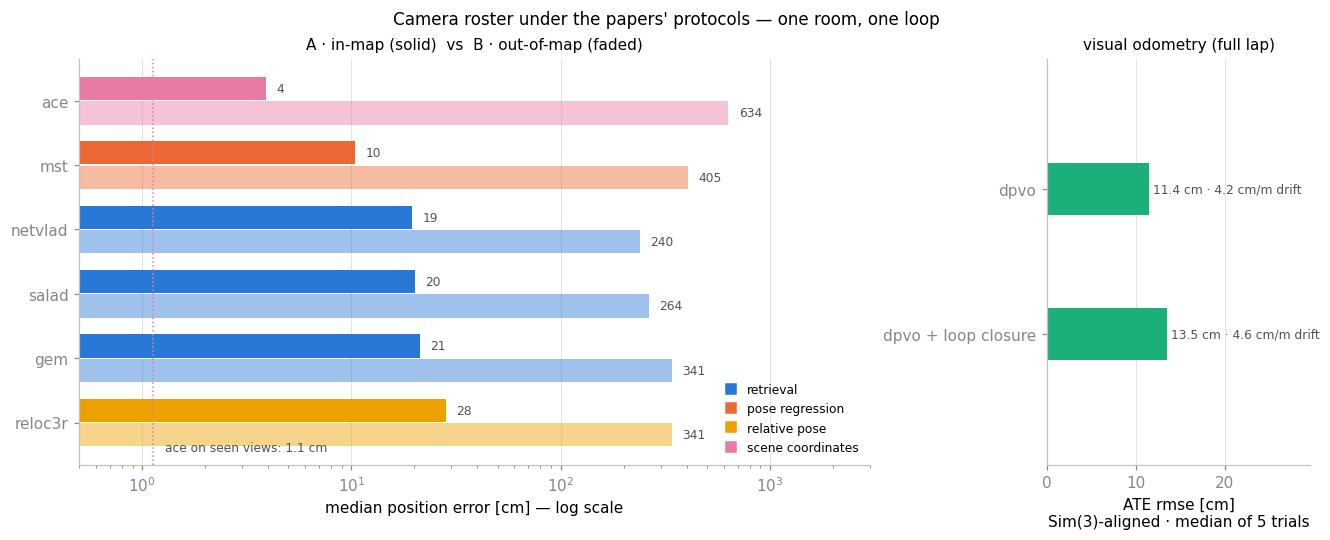

In [24]:
# Section 3 closing: every method under both protocols (log scale), VO in its own panel
METHS = [("netvlad", "retrieval"), ("salad", "retrieval"), ("gem", "retrieval"),
         ("reloc3r", "relative pose"), ("mst", "pose regression"), ("ace", "scene coordinates")]
FAMC = {"retrieval": "#2a78d6", "pose regression": "#eb6834", "relative pose": "#eda100",
        "scene coordinates": "#e87ba4", "visual odometry": "#1baf7a"}
order = sorted(METHS, key=lambda mf: RESULTS[f"{mf[0]}_A"]["med_cm"])
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.8), width_ratios=[3, 1], constrained_layout=True)
yy = np.arange(len(order))
for off, P, alpha in [(-0.19, "A", 1.0), (0.19, "B", 0.45)]:
    vals = [RESULTS[f"{m}_{P}"]["med_cm"] for m, _ in order]
    ax.barh(yy + off, vals, height=0.36, color=[FAMC[f] for _, f in order], alpha=alpha)
    for i, v in enumerate(vals):
        ax.text(v * 1.12, i + off, f"{v:.0f}", va="center", fontsize=8, color="#52514e")
seen = RESULTS["ace_seen_A"]["med_cm"]
ax.axvline(seen, c="#e87ba4", ls=":", lw=1)
ax.text(seen * 1.15, len(order) - 0.55, f"ace on seen views: {seen:.1f} cm", fontsize=8, color="#52514e")
ax.set_yticks(yy, [m for m, _ in order]); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xlim(0.5, 3000); ax.grid(True, axis="x"); ax.set_axisbelow(True)
ax.set_xlabel("median position error [cm] — log scale")
ax.set_title("A · in-map (solid)  vs  B · out-of-map (faded)", fontsize=10)
for f, c in FAMC.items():
    if f != "visual odometry": ax.plot([], [], "s", c=c, label=f)
ax.legend(loc="lower right", frameon=False, fontsize=8, handlelength=1.0)
vo = [("dpvo", RESULTS["dpvo_VO"]), ("dpvo_lc", RESULTS["dpvo_lc_VO"])]
ax2.barh(range(2), [s["ate_rmse_cm"] for _, s in vo], color=FAMC["visual odometry"], height=0.36)
for i, (_, s) in enumerate(vo):
    ax2.text(s["ate_rmse_cm"] + 0.5, i, f"{s['ate_rmse_cm']:.1f} cm · {s['rpe_cm_per_m']:.1f} cm/m drift",
             va="center", fontsize=8, color="#52514e")
ax2.set_yticks(range(2), ["dpvo", "dpvo + loop closure"]); ax2.invert_yaxis()
ax2.set_xlim(0, max(s["ate_rmse_cm"] for _, s in vo) * 2.2); ax2.grid(True, axis="x"); ax2.set_axisbelow(True)
ax2.set_xlabel("ATE rmse [cm]\nSim(3)-aligned · median of 5 trials")
ax2.set_ylim(1.9, -0.9)
ax2.set_title("visual odometry (full lap)", fontsize=10)
fig.suptitle("Camera roster under the papers' protocols — one room, one loop", fontsize=11)
plt.show()

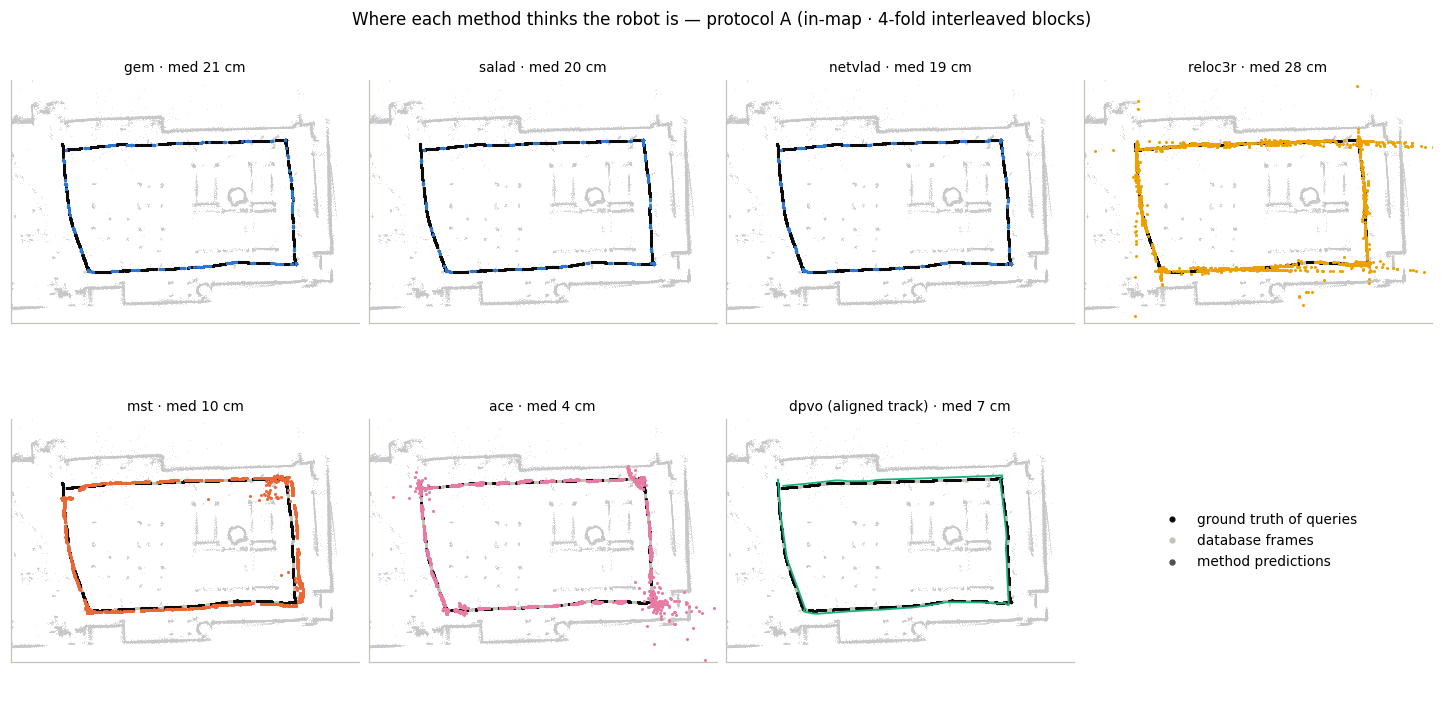

In [25]:
# GT vs prediction, one panel per method (protocol A = in-map): black = query GT, gray = database
SHOW = "A"
mp = np.load(f"{DATA}/ground_truth/map_points.npz")["xy"]
DBs, Qs = sets(SHOW)
Dt = np.loadtxt(f"{RUNS}/dpvo/dpvo_t0.txt"); fidx = Dt[:, 0].astype(int)
A_dp = umeyama(Dt[:, 1:4], G_cam[fidx]); dpvo_err = np.linalg.norm(A_dp - G_cam[fidx], axis=1)
panels = [("gem", "#2a78d6"), ("salad", "#2a78d6"), ("netvlad", "#2a78d6"), ("reloc3r", "#eda100"),
          ("mst", "#eb6834"), ("ace", "#e87ba4"), ("dpvo", "#1baf7a")]
xl = (cam.x.min() - 1.3, cam.x.max() + 1.6); yl = (cam.y.min() - 1.3, cam.y.max() + 1.5)
fig, axes = plt.subplots(2, 4, figsize=(13, 6.4), constrained_layout=True)
for ax, (m, c) in zip(axes.ravel(), panels):
    ax.scatter(*mp.T, s=0.15, c="0.78", lw=0, rasterized=True)
    ax.plot(DBs.x, DBs.y, ".", c="#c3c2b7", ms=1.5)
    ax.plot(Qs.x, Qs.y, ".", c="#0b0b0b", ms=2)
    if m == "dpvo":
        ax.plot(A_dp[:, 0], A_dp[:, 1], c=c, lw=1.2, zorder=3)
        ttl = f"dpvo (aligned track) · med {np.median(dpvo_err)*100:.0f} cm"
    else:
        j = PRED[f"{m}_{SHOW}"]
        ax.scatter(j.x, j.y, s=4, c=c, lw=0, zorder=3)
        ttl = f"{m} · med {RESULTS[f'{m}_{SHOW}']['med_cm']:.0f} cm"
    ax.set_title(ttl, fontsize=9); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlim(*xl); ax.set_ylim(*yl)
ax = axes.ravel()[-1]; ax.axis("off")
ax.plot([], [], ".", c="#0b0b0b", label="ground truth of queries")
ax.plot([], [], ".", c="#c3c2b7", label="database frames")
ax.scatter([], [], s=10, c="#52514e", label="method predictions")
ax.legend(loc="center", frameon=False, fontsize=9)
fig.suptitle(f"Where each method thinks the robot is — protocol {SHOW} ({PROTOCOLS[SHOW]})", fontsize=11)
plt.show()

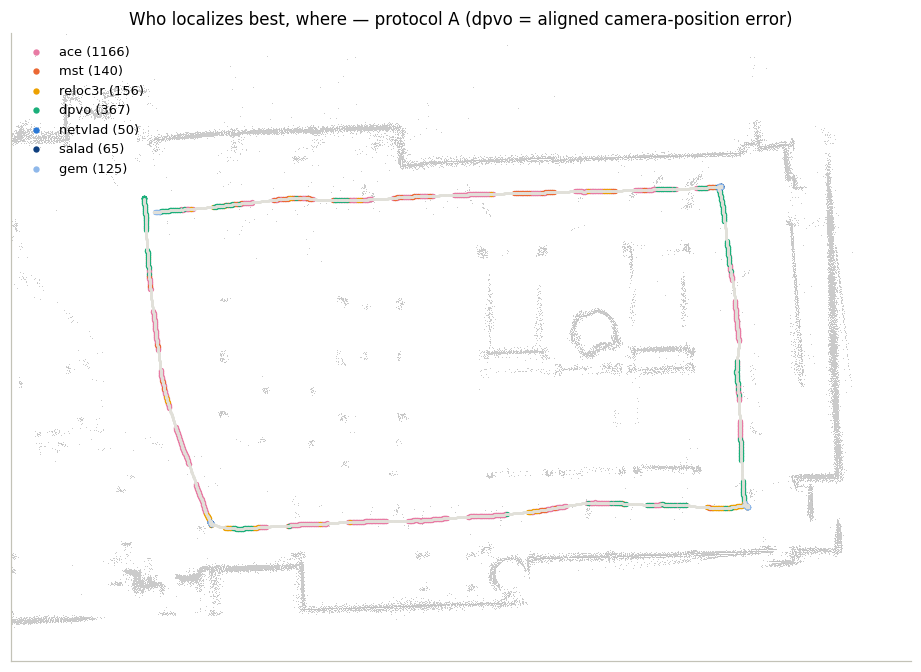

In [26]:
# Creative closer: WHO WINS WHERE (protocol A) — each query colored by the method that localizes it
# best. Complementary win regions = the fusion argument drawn on the floor plan.
E = {m: pd.Series(np.hypot(PRED[f"{m}_{SHOW}"].x - PRED[f"{m}_{SHOW}"].x_gt,
                           PRED[f"{m}_{SHOW}"].y - PRED[f"{m}_{SHOW}"].y_gt).values,
                  index=PRED[f"{m}_{SHOW}"].frame.values) for m, _ in panels if m != "dpvo"}
E["dpvo"] = pd.Series(dpvo_err, index=cam.filename.values[fidx])   # aligned camera-position error
M = pd.DataFrame(E).reindex(Qs.filename.values)
winner, best = M.idxmin(axis=1), M.min(axis=1)
WINC = {"ace": "#e87ba4", "mst": "#eb6834", "reloc3r": "#eda100", "dpvo": "#1baf7a",   # family colours as above
        "netvlad": "#2a78d6", "salad": "#0f3f7e", "gem": "#8fb8ea"}                  # retrieval = three blues
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
ax.scatter(*mp.T, s=0.3, c="0.75", lw=0, rasterized=True)
ax.plot(DBs.x, DBs.y, ".", c="#e1e0d9", ms=1.5)
lost = (best > 0.5).values
if lost.any():
    ax.scatter(Qs.x.values[lost], Qs.y.values[lost], s=14, marker="x", c="#c3c2b7", lw=0.8,
               label=f"nobody within 50 cm ({lost.sum()})")
for m, c in WINC.items():
    sel = ((winner == m).values & ~lost)
    if sel.any():
        ax.scatter(Qs.x.values[sel], Qs.y.values[sel], s=12, c=c, lw=0, label=f"{m} ({sel.sum()})")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.set_xlim(*xl); ax.set_ylim(*yl)
ax.legend(loc="upper left", frameon=False, fontsize=8.5, markerscale=1.2)
ax.set_title(f"Who localizes best, where — protocol {SHOW} (dpvo = aligned camera-position error)", fontsize=11)
plt.show()

In [27]:
# Section 3 in one table — the papers' metrics for every method under both protocols, one row per
# (method, protocol); bold = best of that protocol. VO below in its own rows. Both saved to Drive
# as CSV: the seed of the paper's results table.
FAM = {"ace": "scene coordinates", "mst": "pose regression", "reloc3r": "relative pose",
       "netvlad": "retrieval", "salad": "retrieval", "gem": "retrieval"}
METRIC = {"n": "queries scored", "med_cm": "median position error (cm)", "med_deg": "median heading error (°)",
          "acc_5cm_5deg": "within 5 cm and 5° (%)", "acc_25cm_5deg": "within 25 cm and 5° (%)",
          "r1_1m": "within 1 m (%)"}
order = sorted(FAM, key=lambda m: RESULTS[f"{m}_A"]["med_cm"])
T = pd.DataFrame([{"method": m, "family": FAM[m], "protocol": f"{P} · {PROTOCOLS[P].split(' ·')[0]}",
                   **{lab: RESULTS[f"{m}_{P}"][k] for k, lab in METRIC.items()}}
                  for m in order for P in PROTOCOLS]).set_index(["method", "family", "protocol"])
VO = pd.DataFrame({v: RESULTS[f"{v}_VO"] for v in ["dpvo", "dpvo_lc"]}).T.rename(columns={
    "ate_rmse_cm": "trajectory error RMSE after Sim(3) alignment (cm) · median of 5 trials",
    "ate_med_cm": "trajectory error median (cm)", "rpe_cm_per_m": "drift (cm per metre travelled)"})
VO.index = ["dpvo", "dpvo + loop closure"]; VO = VO.rename_axis("visual odometry · full lap")
T.to_csv(f"{RUNS}/table_camera_A_B.csv"); VO.to_csv(f"{RUNS}/table_camera_VO.csv")
for f in ("table_camera_A_B.csv", "table_camera_VO.csv"): keep(f"{RUNS}/{f}")
lo = [c for c in T.columns if "error" in c]; hi = [c for c in T.columns if c.startswith("within")]
st = T.style.format({c: "{:.1f}" for c in lo + hi}).format({"queries scored": "{:d}"})
for P in T.index.unique("protocol"):                                  # best per column, per protocol
    rows = pd.IndexSlice[:, :, P]
    st = st.highlight_min(subset=(rows, lo), props="font-weight:bold").highlight_max(subset=(rows, hi), props="font-weight:bold")
display(st.set_caption(f"ACE on seen database views (upper bound): A {RESULTS['ace_seen_A']['med_cm']:.1f} cm"
                       f" · B {RESULTS['ace_seen_B']['med_cm']:.1f} cm"))
display(VO.style.format("{:.1f}"))

,trajectory error RMSE after Sim(3) alignment (cm) · median of 5 trials,trajectory error median (cm),drift (cm per metre travelled)
visual odometry · full lap,,,
dpvo,11.4,9.0,4.2
dpvo + loop closure,13.5,11.3,4.6


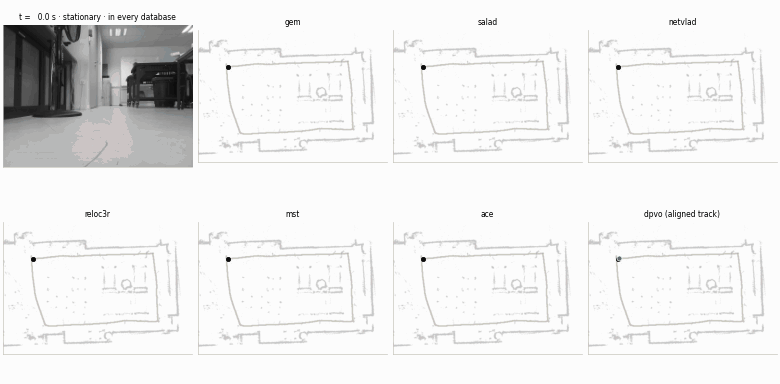

In [28]:
# The whole lap as one animation — live camera frame + every method's estimate as the robot moves.
# Every moving frame is shown as predicted by the fold that held its block out (its model /
# database never saw that block); DPVO's aligned track runs through. Black = truth, colour = the
# method's belief, the short line = its error right now. Per-method GIFs are kept on Drive too.
from PIL import Image as PImage
from IPython.display import Image, display
GIFS = f"{RUNS}/gifs"; os.makedirs(GIFS, exist_ok=True)
if not have(f"{GIFS}/roster_A.gif"):
    STEP, FPS, DPI = 10, 12, 60                          # 30 Hz lap sampled at 3 Hz, played at 12 fps (4x real time)
    est = {}                                             # method -> (x, y) per camera frame, NaN where it has none
    for m, _ in panels:
        e = np.full((len(cam), 2), np.nan)
        if m == "dpvo": e[fidx] = A_dp[:, :2]
        else:
            j = pd.concat([pd.read_csv(f"{RUNS}/{m}_A{k}/pred.csv") for k in range(EVERY)])   # all folds, guard frames included
            e[GTL.index.get_indexer(j.frame)] = j[["x", "y"]].values
        est[m] = e
    f0, a0 = plt.subplots(figsize=(4, 4 * (yl[1] - yl[0]) / (xl[1] - xl[0])), dpi=110)   # backdrop drawn once
    a0.scatter(*mp.T, s=0.3, c="0.78", lw=0); a0.plot(cam.x[cam.db_keep], cam.y[cam.db_keep], ".", c="#c3c2b7", ms=2)
    a0.set_xlim(*xl); a0.set_ylim(*yl); a0.axis("off"); f0.subplots_adjust(0, 0, 1, 1); f0.canvas.draw()
    BG = np.asarray(f0.canvas.buffer_rgba()).copy(); plt.close(f0)
    fig, axes = plt.subplots(2, 4, figsize=(13, 6.4), dpi=DPI, constrained_layout=True)
    ax0 = axes.ravel()[0]; im = ax0.imshow(G[0], cmap="gray", vmin=0, vmax=255); ax0.set_xticks([]); ax0.set_yticks([])
    art = {}
    for ax, (m, c) in zip(axes.ravel()[1:], panels):
        ax.imshow(BG, extent=[*xl, *yl], interpolation="bilinear")
        art[m] = (ax.plot([], [], c="#0b0b0b", lw=0.8)[0],                                       # truth so far
                  ax.plot([], [], "-" if m == "dpvo" else ".", c=c, lw=1.2, ms=3, alpha=0.7)[0],   # estimates so far
                  ax.plot([], [], c=c, lw=1.5)[0],                                                # truth -> estimate, now
                  ax.plot([], [], "o", c="#0b0b0b", ms=5)[0],
                  ax.plot([], [], "o", c=c, ms=6, mec="white", mew=0.8)[0])
        ax.set_title(m if m != "dpvo" else "dpvo (aligned track)", fontsize=9)
        ax.set_xlim(*xl); ax.set_ylim(*yl); ax.set_xticks([]); ax.set_yticks([])
    gx, gy, fold, tt = cam.x.values, cam.y.values, cam.fold.values, cam.t.values
    frames = []
    for i in range(0, len(cam), STEP):
        im.set_data(G[i])
        ax0.set_title(f"t = {tt[i]:5.1f} s · " + (f"held out by fold {fold[i]}" if fold[i] >= 0 else "stationary · in every database"), fontsize=9)
        for m, (tr, es, er, gn, en) in art.items():
            e = est[m]; tr.set_data(gx[:i + 1], gy[:i + 1]); gn.set_data([gx[i]], [gy[i]]); es.set_data(*e[:i + 1].T)
            en.set_data([e[i, 0]], [e[i, 1]]); er.set_data([gx[i], e[i, 0]], [gy[i], e[i, 1]])
        fig.canvas.draw()
        frames.append(PImage.fromarray(np.asarray(fig.canvas.buffer_rgba())[..., :3]))
    pal = frames[len(frames) // 2].quantize(colors=128)                  # one shared palette -> small deltas
    q = [f.quantize(palette=pal, dither=PImage.Dither.NONE) for f in frames]
    q[0].save(f"{GIFS}/roster_A.gif", save_all=True, append_images=q[1:], duration=1000 // FPS, loop=0)
    H = frames[0].height
    for ax, (m, _) in zip(axes.ravel()[1:], panels):                      # per-method GIFs = panel crops
        b = ax.get_tightbbox(fig.canvas.get_renderer())
        crop = [f.crop((int(b.x0), int(H - b.y1), int(b.x1) + 1, int(H - b.y0) + 1)) for f in q]
        crop[0].save(f"{GIFS}/{m}_A.gif", save_all=True, append_images=crop[1:], duration=1000 // FPS, loop=0)
    plt.close(fig)
    for f in os.listdir(GIFS): keep(f"{GIFS}/{f}")
display(Image(f"{GIFS}/roster_A.gif"))